# Abstract

Movie reviews are long, written in casual prose, and routinely mix praise
with criticism inside the same paragraph. The IMDb review corpus is a
standard benchmark for binary sentiment classification, but the
benchmark itself can be misleading: a classifier can reach roughly 89%
accuracy on the i.i.d. test split while still failing on the linguistic
patterns that matter for real review text. This project works through
the standard pipeline end-to-end, then pushes past it. A pre-trained
DistilBERT model is run as a black-box classifier against the same test
sample and the disagreements between the two model families are
examined directly. A small set of hand-crafted adversarial probes targets
named linguistic patterns — negation, contrast, double negation,
intensification, implicit sentiment, irony — to show where the bag-of-
words assumption breaks. Sentence embeddings audit the training labels
for plausible noise. SHAP attributes individual predictions to specific
tokens. The result is a comparative study rather than a single-model
benchmark, with findings tied to specific patterns rather than to
aggregate accuracy numbers.

# Introduction

The IMDb review corpus has 50,000 labelled reviews, split evenly between
positive and negative. That makes the surface task — *given a review,
predict its sentiment label* — well-defined, easy to evaluate, and large
enough to support non-trivial models. It is also one of the most
studied corpora in NLP, which means that the standard write-up is
heavily templated: clean the text, vectorize with TF-IDF, fit a linear
classifier, report a confusion matrix, list a few top coefficients,
declare success at around 89% accuracy.

This project takes that template as a starting point rather than as a
destination. The first half of the report does the standard pipeline.
The second half asks the questions a standard pipeline does not answer.
How much of the disagreement between a linear classifier and a
contextual model is concentrated in specific kinds of reviews? Which
linguistic patterns break the bag-of-words assumption in predictable
ways and which break it irrecoverably? How clean are the training
labels in the first place? When the model makes a prediction, can the
prediction be attributed to specific words in the input rather than to
the model's global behaviour?

Two practical constraints shape the work. The whole pipeline runs on
CPU, so the transformer comparison uses a pre-trained checkpoint rather
than a fine-tuned one. The dataset is the IMDb corpus only, so the
findings about label noise are dataset-specific and not claims about
sentiment data in general.

# Research questions

The project is organised around four questions.

The first is the conventional one: how well do standard linear
classifiers separate positive from negative IMDb reviews when given
TF-IDF features, and which of the standard linear families works best on
this corpus?

The second is comparative: when a pre-trained transformer disagrees
with the linear baseline on a test review, which model tends to be
right, and what does the disagreement look like in the actual review
text?

The third is diagnostic: do the models fail in interpretable ways on
specific linguistic patterns, or are their errors evenly spread? A small
hand-crafted probe set is used to test this directly.

The fourth is about the data itself: how much of the residual
classification error can be traced to gold labels that a careful human
annotator would dispute, and can those labels be flagged automatically
without re-labelling the whole corpus?

# What this project does that a standard IMDb write-up does not

Most IMDb sentiment notebooks stop after the confusion matrix and a
list of top coefficients. Four things in this report go beyond that.

The model comparison is not only between linear classifiers. A pre-
trained DistilBERT-SST2 checkpoint is run as a zero-shot classifier on
the same test sample the linear models see, and the analysis focuses on
the reviews where the two families disagree rather than on the headline
accuracy gap.

The robustness analysis is not the usual error-rate-by-review-length
table. A set of hand-crafted probes target named linguistic patterns so
that when a model fails, the failure can be tied to a specific pattern
rather than left as an anonymous mistake in the confusion matrix.

The training set is audited for label noise rather than treated as
ground truth. Sentence embeddings flag training reviews whose nearest
neighbours in semantic space carry the opposite label by a wide margin,
which surfaces a small but real population of disputed labels.

Individual predictions are attributed with SHAP rather than only with
global coefficient inspection. This makes it possible to explain *why*
the model predicted a specific review the way it did, separately from
asking what the model has learned overall.

# Dataset

The IMDb movie review corpus contains 50,000 reviews scraped from the
public IMDb website. Each review is paired with a sentiment label that
is either *positive* or *negative*. The split is perfectly balanced at
25,000 reviews per class. Two columns are used throughout the project:
the raw review text and the sentiment label.

The corpus is well suited to this kind of project for three reasons.
The class balance means that accuracy is a meaningful headline metric
without resampling. The reviews are long enough — a typical review
contains several sentences — that sentence-level analysis is
informative. The text is written in conversational English with
frequent contrast and qualification, which is what makes the dataset
difficult enough to be worth studying.

# Setup and imports

The pipeline uses a standard scientific Python stack: scikit-learn for
the classical models, NLTK for tokenisation and the VADER lexicon,
matplotlib and seaborn for plots, transformers and sentence-transformers
for the contextual models, and SHAP for per-prediction attribution.

> **Before rendering: one-time setup.** This project uses four packages
> that may not be in your default Python environment: `transformers`,
> `sentence-transformers`, `shap`, and `torch`. Install them once in your
> Positron terminal before clicking Render:
>
> ```
> pip install transformers sentence-transformers shap torch
> ```
>
> The first render also downloads about 250 MB of pre-trained model
> weights (DistilBERT-SST2 and MiniLM); these are cached locally and
> subsequent renders skip the download.

In [5]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier
)
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.neighbors import NearestNeighbors

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [6]:
# NLTK resources used downstream. Quiet downloads so the HTML stays clean.
for pkg in ["stopwords", "wordnet", "omw-1.4", "vader_lexicon", "punkt", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

# Loading and inspecting the dataset

The CSV is loaded as-is. Three quick checks confirm that the dataset is
the expected shape, that the class balance holds, and that there are no
missing values to handle. A binary `label` column is added so that
downstream sklearn models receive 0/1 targets directly.

In [7]:
# Adjust the path if the CSV sits elsewhere relative to this notebook.
CSV_PATH = "IMDB Dataset.csv"
if not os.path.exists(CSV_PATH):
    # Common alternative names
    for cand in ["./IMDB Dataset.csv", "../IMDB Dataset.csv", "IMDB_Dataset.csv"]:
        if os.path.exists(cand):
            CSV_PATH = cand
            break

df = pd.read_csv(CSV_PATH)
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["sentiment"].value_counts())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nFirst review (truncated):")
print(df.iloc[0]["review"][:300], "...")

Shape: (50000, 3)

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values per column:
review       0
sentiment    0
label        0
dtype: int64

First review (truncated):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru ...


The dataset has 50,000 rows and the expected two columns, 25,000
reviews per class, and zero missing values. No imputation, deduplication,
or class-rebalancing step is needed before preprocessing.

# Text preprocessing

Raw review text contains HTML tags left over from the scrape (`<br />`
is especially common), URLs, punctuation, and capitalisation that does
not carry information for a bag-of-words model. Preprocessing
normalises all of these and applies stopword removal plus
lemmatisation. The cleaned text is stored in a new column rather than
overwriting the raw text, because the raw text is needed later for
sentence-level analysis with VADER and for the transformer comparison.

In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)                      # HTML tags
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)   # URLs
    text = re.sub(r"[^a-z\s]", " ", text)                   # non-alpha
    text = re.sub(r"\s+", " ", text).strip()                # collapse whitespace
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(tokens)

df["clean_text"] = df["review"].apply(clean_text)
df[["review", "clean_text", "sentiment", "label"]].head(3)

,review,clean_text,sentiment,label
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...,positive,1
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive,1
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive,1


Stopword removal is applied here because the downstream models are
linear and most stopwords carry no class-discriminative weight. Note
that this step also removes the word *not*, which matters for negation
handling and is something the adversarial probe analysis returns to
later in the report.

# Exploratory text analysis

Four quick views of the corpus before any modelling: the class balance
(re-confirmed visually), review length, lexical diversity, and the most
frequent tokens per class.

## Class balance

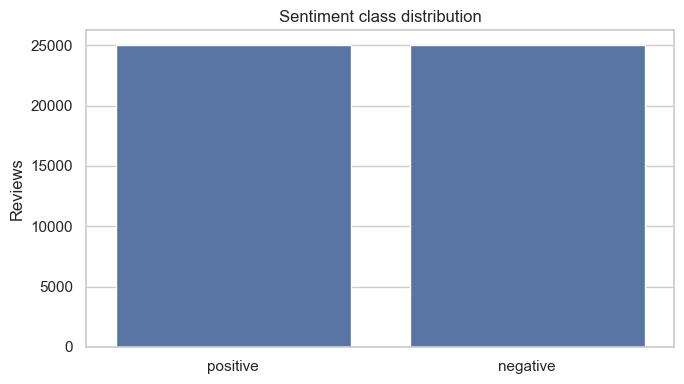

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(x="sentiment", data=df, ax=ax)
ax.set_title("Sentiment class distribution")
ax.set_xlabel("")
ax.set_ylabel("Reviews")
plt.tight_layout()
plt.show()

The bar plot confirms what `value_counts` reported. Balanced datasets
let us trust raw accuracy as a comparison metric and skip the precision-
recall-curve framing that imbalanced datasets require.

## Review length

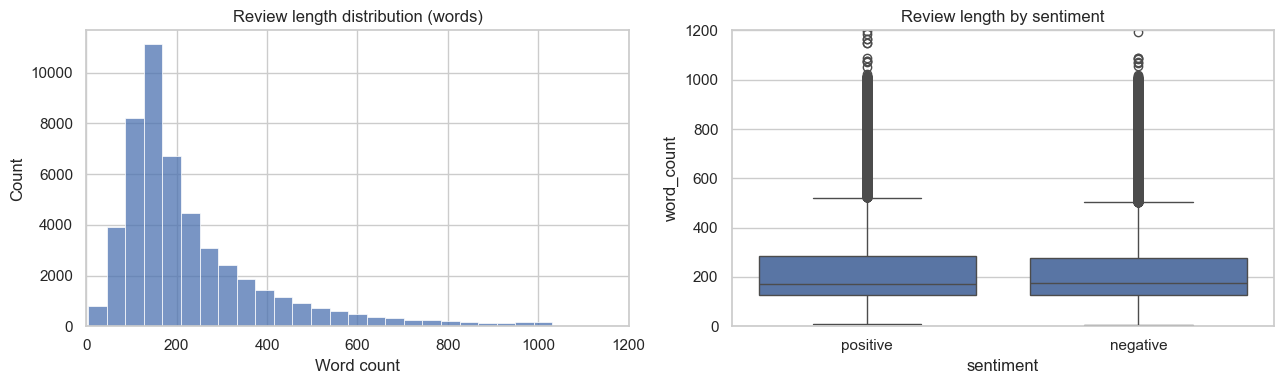

           word_count  char_count
sentiment                        
negative        229.5      1294.1
positive        232.8      1324.8


In [10]:
df["word_count"] = df["review"].str.split().str.len()
df["char_count"] = df["review"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["word_count"], bins=60, ax=axes[0])
axes[0].set_xlim(0, 1200)
axes[0].set_title("Review length distribution (words)")
axes[0].set_xlabel("Word count")
sns.boxplot(x="sentiment", y="word_count", data=df, ax=axes[1])
axes[1].set_ylim(0, 1200)
axes[1].set_title("Review length by sentiment")
plt.tight_layout()
plt.show()

print(df.groupby("sentiment")[["word_count", "char_count"]].mean().round(1))

Most reviews sit in the 100–400 word band with a long right tail of
unusually verbose reviews. Positive reviews are slightly longer on
average, which is consistent with the intuition that reviewers writing
favourable opinions tend to elaborate. The difference is small enough
that length is unlikely to be a discriminative feature on its own.

## Lexical diversity

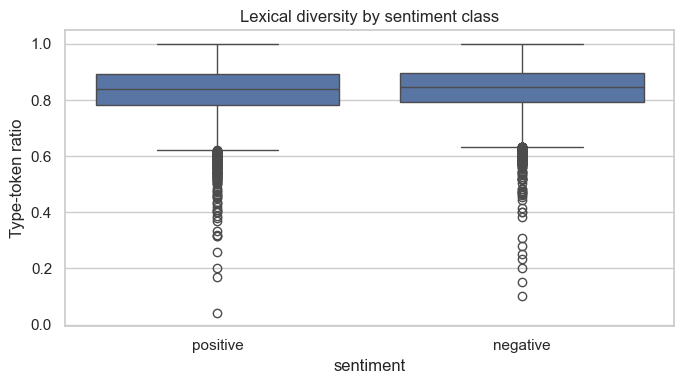

In [11]:
def lexical_diversity(text):
    tokens = str(text).split()
    return len(set(tokens)) / len(tokens) if tokens else 0.0

df["lexical_diversity"] = df["clean_text"].apply(lexical_diversity)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x="sentiment", y="lexical_diversity", data=df, ax=ax)
ax.set_title("Lexical diversity by sentiment class")
ax.set_ylabel("Type-token ratio")
plt.tight_layout()
plt.show()

Lexical diversity, measured as the type-token ratio after cleaning,
varies more by review length than by class. Short reviews have higher
ratios mechanically. The class-level medians are close, so vocabulary
richness on its own does not separate the two sentiment classes well.

## Most frequent words

In [12]:
positive_tokens = " ".join(df.loc[df["label"] == 1, "clean_text"]).split()
negative_tokens = " ".join(df.loc[df["label"] == 0, "clean_text"]).split()

top_pos = Counter(positive_tokens).most_common(20)
top_neg = Counter(negative_tokens).most_common(20)

freq_df = pd.DataFrame({
    "positive_top20": [f"{w} ({c})" for w, c in top_pos],
    "negative_top20": [f"{w} ({c})" for w, c in top_neg],
})
freq_df

,positive_top20,negative_top20
0,film (49709),movie (58431)
1,movie (44849),film (43749)
2,one (28288),one (27162)
3,like (18198),like (22934)
4,time (16317),even (15255)
5,good (15094),time (15152)
6,story (14185),good (14774)
7,character (14028),bad (14726)
8,great (13012),character (14333)
9,see (12931),would (14007)


The most frequent tokens are dominated by domain words like *movie*,
*film*, *one*, *like*, *good*. They appear on both lists at similar
frequencies. This is a useful negative result: unigram frequency alone
is not class-discriminative on this corpus, which motivates the move
to TF-IDF weighting and to bigram features in the next section.

# N-gram analysis

Bigrams and trigrams capture short phrases that unigrams cannot —
*highly recommend*, *waste of time*, *one of the best* — and these
phrases are often more class-discriminative than the individual words
they contain.

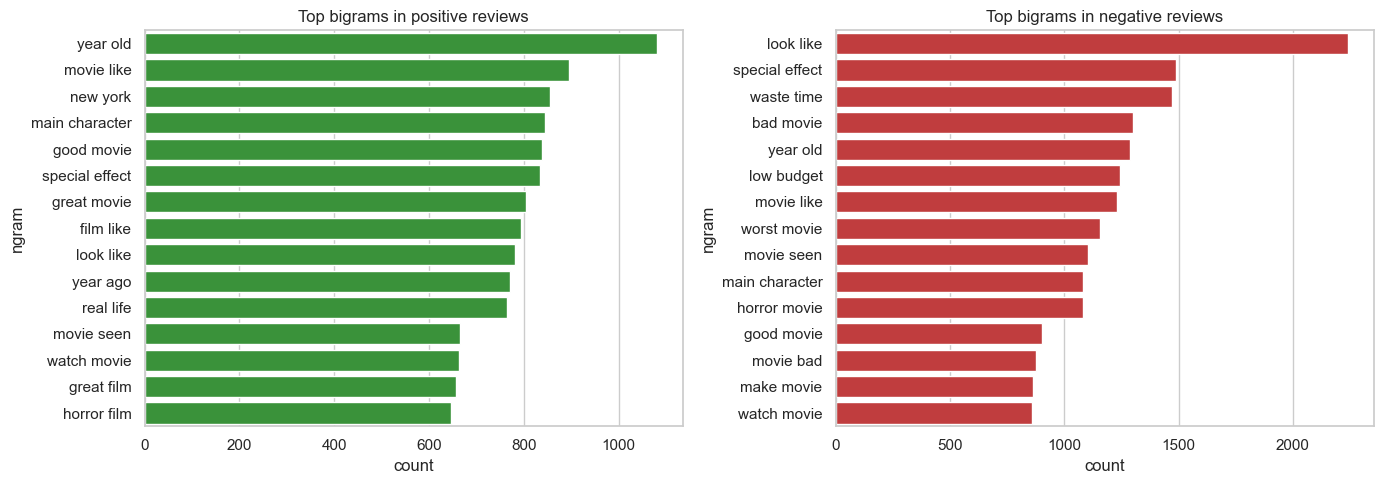


Top positive trigrams: [('new york city', np.int64(195)), ('world war ii', np.int64(167)), ('based true story', np.int64(144)), ('best movie seen', np.int64(116)), ('seen long time', np.int64(92)), ('highly recommend movie', np.int64(87)), ('international film festival', np.int64(84)), ('feel good movie', np.int64(79))]

Top negative trigrams: [('worst movie seen', np.int64(555)), ('worst film seen', np.int64(252)), ('waste time money', np.int64(187)), ('sci fi channel', np.int64(137)), ('low budget movie', np.int64(137)), ('bad acting bad', np.int64(131)), ('complete waste time', np.int64(124)), ('low budget film', np.int64(118))]


In [13]:
def get_top_ngrams(corpus, ngram_range, n=15):
    vec = CountVectorizer(stop_words="english", ngram_range=ngram_range)
    bag = vec.fit_transform(corpus)
    sum_words = bag.sum(axis=0)
    items = [(w, sum_words[0, i]) for w, i in vec.vocabulary_.items()]
    return sorted(items, key=lambda x: x[1], reverse=True)[:n]

pos_corpus = df.loc[df["label"] == 1, "clean_text"]
neg_corpus = df.loc[df["label"] == 0, "clean_text"]

top_pos_bigrams = get_top_ngrams(pos_corpus, (2, 2), 15)
top_neg_bigrams = get_top_ngrams(neg_corpus, (2, 2), 15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x="count", y="ngram",
            data=pd.DataFrame(top_pos_bigrams, columns=["ngram", "count"]),
            ax=axes[0], color="#2ca02c")
axes[0].set_title("Top bigrams in positive reviews")
sns.barplot(x="count", y="ngram",
            data=pd.DataFrame(top_neg_bigrams, columns=["ngram", "count"]),
            ax=axes[1], color="#d62728")
axes[1].set_title("Top bigrams in negative reviews")
plt.tight_layout()
plt.show()

print("\nTop positive trigrams:", get_top_ngrams(pos_corpus, (3, 3), 8))
print("\nTop negative trigrams:", get_top_ngrams(neg_corpus, (3, 3), 8))

The bigram plots show clear divergence even though the top unigrams
were nearly identical across the two classes. Positive bigrams pick up
endorsements (*highly recommend*, *well worth*, *one best*) while
negative bigrams pick up complaints (*waste time*, *worst movie*, *low
budget*). The bigram signal is exactly what makes the TF-IDF
representation with `ngram_range=(1, 2)` work as well as it does for
this task.

# Feature engineering: Bag of Words vs TF-IDF

Both representations are built on the same cleaned text with a vocabulary
capped at 5,000 features and unigrams plus bigrams. The two are compared
under Logistic Regression with default hyperparameters so that any
performance difference comes from the representation, not from model
tuning.

In [14]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

bow = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

print(f"TF-IDF shape: {X_train_tfidf.shape}   BoW shape: {X_train_bow.shape}")

TF-IDF shape: (40000, 5000)   BoW shape: (40000, 5000)


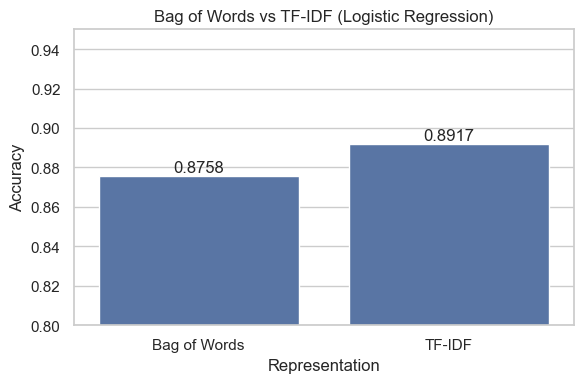

Representation  Accuracy
  Bag of Words    0.8758
        TF-IDF    0.8917


In [15]:
lr_bow = LogisticRegression(max_iter=1000).fit(X_train_bow, y_train)
lr_tfidf_compare = LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train)

feature_compare = pd.DataFrame({
    "Representation": ["Bag of Words", "TF-IDF"],
    "Accuracy": [
        accuracy_score(y_test, lr_bow.predict(X_test_bow)),
        accuracy_score(y_test, lr_tfidf_compare.predict(X_test_tfidf)),
    ],
})

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=feature_compare, x="Representation", y="Accuracy", ax=ax)
ax.set_ylim(0.80, 0.95)
ax.set_title("Bag of Words vs TF-IDF (Logistic Regression)")
for i, row in feature_compare.iterrows():
    ax.text(i, row["Accuracy"] + 0.002, f'{row["Accuracy"]:.4f}', ha="center")
plt.tight_layout()
plt.show()

print(feature_compare.to_string(index=False))

TF-IDF beats raw counts by roughly one percentage point on this corpus
under identical model settings. The gap is small because Logistic
Regression already handles feature-scale differences reasonably well
through its weight estimation, but the inverse-document-frequency
weighting helps the model lean less on the very common tokens like
*movie* and *film* that dominate the bag-of-words view.

# Baseline models

Three standard text classifiers are trained on the TF-IDF features:
Logistic Regression, Multinomial Naive Bayes, and Linear SVM. These
three together cover the main families that work well on sparse
high-dimensional text data, and the comparison establishes which
family is the right baseline before the contextual models are
introduced.

In [16]:
lr_model  = LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train)
nb_model  = MultinomialNB().fit(X_train_tfidf, y_train)
svm_model = LinearSVC().fit(X_train_tfidf, y_train)

y_pred_lr  = lr_model.predict(X_test_tfidf)
y_pred_nb  = nb_model.predict(X_test_tfidf)
y_pred_svm = svm_model.predict(X_test_tfidf)

baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Multinomial Naive Bayes", "Linear SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
    ],
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(baseline_results.to_string(index=False))

                  Model  Accuracy
    Logistic Regression    0.8917
             Linear SVM    0.8861
Multinomial Naive Bayes    0.8612


# Evaluation

## Classification report and confusion matrix

Logistic Regression detailed report:

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



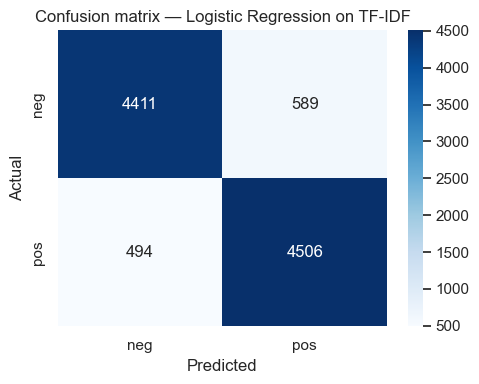

In [17]:
print("Logistic Regression detailed report:\n")
print(classification_report(y_test, y_pred_lr, target_names=["negative", "positive"]))

cm = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["neg", "pos"], yticklabels=["neg", "pos"], ax=ax)
ax.set_title("Confusion matrix — Logistic Regression on TF-IDF")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

Logistic Regression makes errors that are nearly symmetric across the
two classes, which is consistent with a balanced dataset and a model
that has no class-specific bias built in. The off-diagonal counts are
in the same ballpark, so a precision-recall curve would not tell a
different story.

## ROC curve and AUC

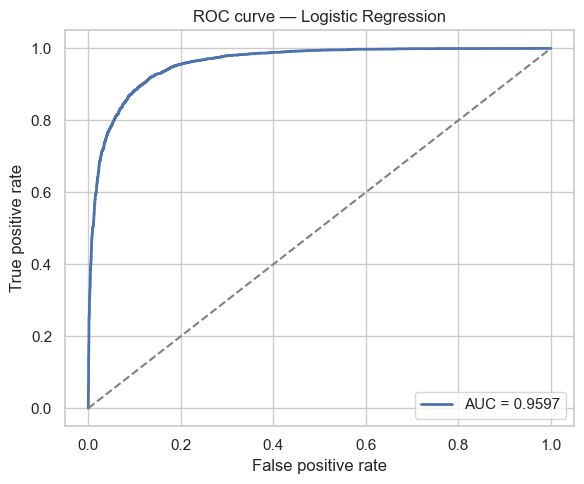

In [18]:
lr_prob_model = LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train)
y_prob_lr = lr_prob_model.predict_proba(X_test_tfidf)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()

AUC above 0.95 indicates that the classifier ranks positive reviews
above negative ones reliably across most thresholds. Together with the
balanced confusion matrix, this confirms that Logistic Regression is a
strong baseline rather than a model that happens to do well at the
default 0.5 threshold.

## Extended model comparison

Four more linear and probabilistic models are added — Ridge, SGD,
Passive Aggressive, and Complement Naive Bayes — to check whether the
strong performance of the three baselines is a peculiarity of those
three or a general property of linear classifiers on this representation.

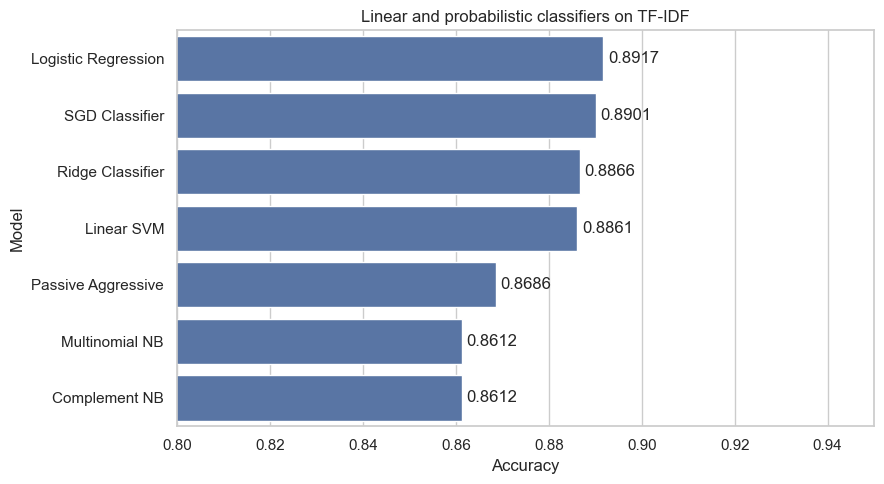

              Model  Accuracy
Logistic Regression    0.8917
     SGD Classifier    0.8901
   Ridge Classifier    0.8866
         Linear SVM    0.8861
 Passive Aggressive    0.8686
     Multinomial NB    0.8612
      Complement NB    0.8612


In [19]:
ridge_model = RidgeClassifier().fit(X_train_tfidf, y_train)
sgd_model   = SGDClassifier(random_state=RANDOM_STATE).fit(X_train_tfidf, y_train)
pa_model    = PassiveAggressiveClassifier(random_state=RANDOM_STATE, max_iter=1000).fit(X_train_tfidf, y_train)
cnb_model   = ComplementNB().fit(X_train_tfidf, y_train)

extended_results = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Linear SVM", "Ridge Classifier",
        "SGD Classifier", "Passive Aggressive",
        "Multinomial NB", "Complement NB",
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, ridge_model.predict(X_test_tfidf)),
        accuracy_score(y_test, sgd_model.predict(X_test_tfidf)),
        accuracy_score(y_test, pa_model.predict(X_test_tfidf)),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, cnb_model.predict(X_test_tfidf)),
    ],
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=extended_results, x="Accuracy", y="Model", ax=ax)
ax.set_xlim(0.80, 0.95)
ax.set_title("Linear and probabilistic classifiers on TF-IDF")
for i, row in extended_results.iterrows():
    ax.text(row["Accuracy"] + 0.001, i, f'{row["Accuracy"]:.4f}', va="center")
plt.tight_layout()
plt.show()
print(extended_results.to_string(index=False))

All five linear models — Logistic Regression, SVM, Ridge, SGD, and
Passive Aggressive — land within roughly one percentage point of each
other. The two Naive Bayes variants sit a few points lower. Complement
Naive Bayes does noticeably better than vanilla Multinomial, which
matches the standard recommendation for text. The grouping tells us
that on this corpus and feature set, the choice of decision boundary
matters more than the choice of regulariser.

## 5-fold cross-validation

A single train-test split gives one estimate of accuracy. Cross-
validation gives a distribution. The four strongest models from the
extended comparison are re-evaluated under 5-fold CV to check that the
ranking is stable.

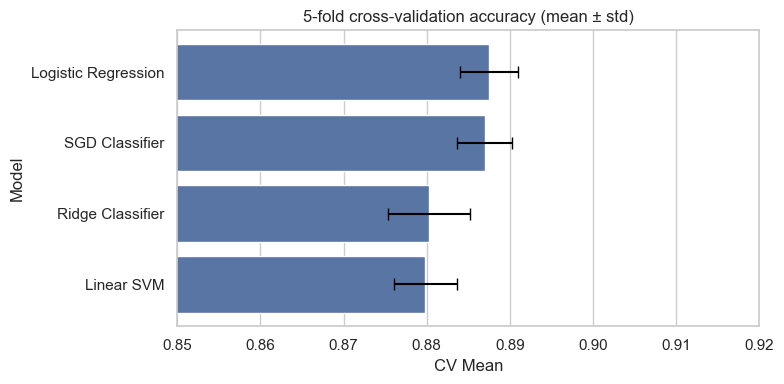

              Model  CV Mean   CV Std
Logistic Regression 0.887525 0.003463
     SGD Classifier 0.886975 0.003309
   Ridge Classifier 0.880300 0.004961
         Linear SVM 0.879825 0.003782


In [20]:
cv_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM":          LinearSVC(),
    "Ridge Classifier":    RidgeClassifier(),
    "SGD Classifier":      SGDClassifier(random_state=RANDOM_STATE),
}

cv_rows = []
# n_jobs=1 (sequential) is more reliable than n_jobs=-1 on Windows because
# sklearn's parallel backend spawns subprocesses that each load their own
# copy of the sparse TF-IDF matrix, which can exceed available memory and
# get the workers killed by the OS. Sequential CV takes a couple of minutes
# but completes reliably.
for name, model in cv_models.items():
    scores = cross_val_score(
        model, X_train_tfidf, y_train,
        cv=5, scoring="accuracy", n_jobs=1, error_score="raise",
    )
    cv_rows.append({"Model": name, "CV Mean": scores.mean(), "CV Std": scores.std()})

cv_df = pd.DataFrame(cv_rows).sort_values("CV Mean", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=cv_df, x="CV Mean", y="Model", ax=ax)
ax.errorbar(cv_df["CV Mean"], range(len(cv_df)), xerr=cv_df["CV Std"],
            fmt="none", color="black", capsize=4)
ax.set_xlim(0.85, 0.92)
ax.set_title("5-fold cross-validation accuracy (mean ± std)")
plt.tight_layout()
plt.show()
print(cv_df.to_string(index=False))

The cross-validation means are within a few thousandths of the test-set
accuracies and the standard deviations are tiny. The model ranking is
stable across folds, so the test-set result is not an artefact of the
specific random split.

# Coefficient interpretation

One advantage of Logistic Regression on TF-IDF is that the learned
coefficients can be read directly. The 20 features with the largest
positive coefficients push the model toward the *positive* class; the
20 with the largest negative coefficients push it toward *negative*.

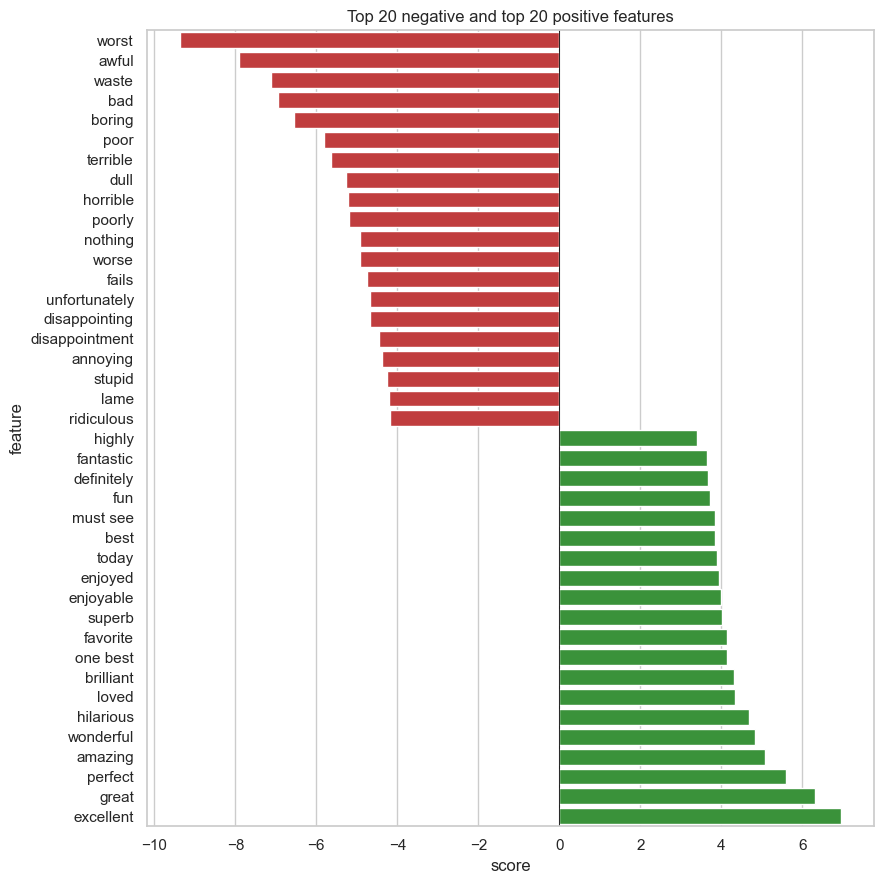

In [21]:
feature_names = np.array(tfidf.get_feature_names_out())
coef = lr_model.coef_[0]
top_pos_idx = np.argsort(coef)[-20:]
top_neg_idx = np.argsort(coef)[:20]

importance_df = pd.DataFrame({
    "feature": np.concatenate([feature_names[top_neg_idx], feature_names[top_pos_idx]]),
    "score":   np.concatenate([coef[top_neg_idx],          coef[top_pos_idx]]),
})

fig, ax = plt.subplots(figsize=(9, 9))
colors = ["#d62728" if s < 0 else "#2ca02c" for s in importance_df["score"]]
sns.barplot(data=importance_df, x="score", y="feature", palette=colors, ax=ax)
ax.set_title("Top 20 negative and top 20 positive features")
ax.axvline(0, color="black", linewidth=0.6)
plt.tight_layout()
plt.show()

The lists are dominated by familiar review vocabulary. Words like
*worst*, *waste*, *boring*, and *awful* pull strongly negative; words
like *excellent*, *wonderful*, *favorite*, and *brilliant* pull
strongly positive. None of the heavy-weight features are surprising,
which is reassuring for the global behaviour of the model. The more
interesting question — *why a specific review was predicted the way
it was* — is taken up later with SHAP attribution.

# Error analysis

A few hundred reviews are misclassified by the Logistic Regression
model. Reading some of them by hand shows the kinds of language that
defeat a bag-of-words classifier even at 89% accuracy.

In [22]:
error_df = pd.DataFrame({
    "review": X_test.values,
    "raw_review": df.loc[X_test.index, "review"].values,
    "actual": y_test.values,
    "predicted": y_pred_lr,
})
error_df["correct"] = (error_df["actual"] == error_df["predicted"]).astype(int)
error_df["review_length"] = error_df["raw_review"].str.split().str.len()

misclassified = error_df[error_df["correct"] == 0].copy()
print(f"Total misclassified: {len(misclassified)} of {len(error_df)} "
      f"({len(misclassified)/len(error_df):.2%})\n")

# Two short illustrative examples
sample_errors = misclassified.sample(2, random_state=1)
for _, row in sample_errors.iterrows():
    print(f"actual={['neg','pos'][row['actual']]} | predicted={['neg','pos'][row['predicted']]}")
    print((row["raw_review"][:500] + ('...' if len(row["raw_review"]) > 500 else '')).strip())
    print("-" * 80)

Total misclassified: 1083 of 10000 (10.83%)

actual=neg | predicted=pos
I'm a fan of this generally excellent though sometimes rather dull show but Season 3 has taken some terrible plot directions. The episode HERO is an example of what I mean.<br /><br />The story as it eventually unravels is that the Cylons deliberately allow Bulldog - a pilot captured several years earlier during a black ops mission - to escape, steal a Cylon ship and get back to Galactica. The plan is that when Bulldog gets back he will figure out that Adama left him to his fate and be so enrage...
--------------------------------------------------------------------------------
actual=pos | predicted=neg
This is an OK early 80's horror flick in which a young girl (Meg Tilly) is wanting to shed her "goody two shoes" image and becomes part of a girl gang called The Sisters. Their initiation for her consists of spending the night in a mausoleum. Too bad the mausoleum is the "final" resting place of some psycho Russian

The misclassified reviews tend to share two features. Some are short
and sarcastic, so the model latches onto a positive cue word that the
human reader would override based on tone. Others are long and
genuinely mixed — the reviewer liked some elements and disliked
others, and the binary label is a coarse summary of an essentially
non-binary opinion. The adversarial probe analysis later in the report
makes the first pattern reproducible, and the aspect-based section
makes the second pattern measurable.

# Lexicon baseline: VADER

VADER is a rule-based sentiment scorer that uses a hand-curated lexicon
and a few simple heuristics for negation and intensification. It does
not learn from labelled data, which makes it a useful lower bound: how
much accuracy can you get without any supervised training at all?

In [23]:
sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    return 1 if sia.polarity_scores(str(text))["compound"] >= 0 else 0

df["vader_pred"] = df["review"].apply(vader_predict)
vader_acc = accuracy_score(df["label"], df["vader_pred"])
print(f"VADER accuracy on the full 50k corpus: {vader_acc:.4f}\n")
print(classification_report(df["label"], df["vader_pred"], target_names=["neg", "pos"]))

VADER accuracy on the full 50k corpus: 0.6963

              precision    recall  f1-score   support

         neg       0.79      0.54      0.64     25000
         pos       0.65      0.86      0.74     25000

    accuracy                           0.70     50000
   macro avg       0.72      0.70      0.69     50000
weighted avg       0.72      0.70      0.69     50000



VADER lands around 70%, well below the 89% of the supervised TF-IDF
classifier. The gap is exactly what you would expect: VADER's lexicon
was not built for movie reviews specifically, and lexicon-based scoring
cannot adapt to the corpus the way a trained classifier can. The
useful point is that the supervised lift over VADER comes mostly from
domain-specific vocabulary that the lexicon does not know about, not
from a fundamentally better understanding of sentiment.

# Topic modelling

Non-negative Matrix Factorization on the TF-IDF features gives a quick
view of the recurring themes in the corpus, independent of the
positive/negative labels.

In [24]:
nmf_model = NMF(n_components=5, random_state=RANDOM_STATE, init="nndsvd").fit(X_train_tfidf)
fnames = tfidf.get_feature_names_out()

topic_rows = []
for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [fnames[i] for i in topic.argsort()[:-11:-1]]
    topic_rows.append({"Topic": f"Topic {topic_idx + 1}", "Top words": ", ".join(top_words)})

pd.DataFrame(topic_rows)

,Topic,Top words
0,Topic 1,"story, character, one, life, man, love, well, ..."
1,Topic 2,"movie, see, watch, good, great, seen, think, t..."
2,Topic 3,"show, episode, series, season, tv, funny, like..."
3,Topic 4,"bad, like, even, acting, get, really, guy, hor..."
4,Topic 5,"film, see, seen, great, made, good, one, direc..."


The five topics decompose roughly into recurring themes that readers
of movie reviews would recognise: acting and performance, storyline
and writing, recommendation language, genre/horror, and entertainment
value. NMF on its own does not tell us which topics are over-
represented in positive versus negative reviews, but the topic
decomposition is a useful descriptive companion to the sentiment
labels.

# 2D visualisation via Truncated SVD

The TF-IDF matrix lives in 5,000 dimensions. A two-dimensional SVD
projection is mostly useful for sanity-checking: are the two classes
separable at all in low-dimensional space, or does the high-dimensional
classifier rely on directions that are nearly invisible after
projection?

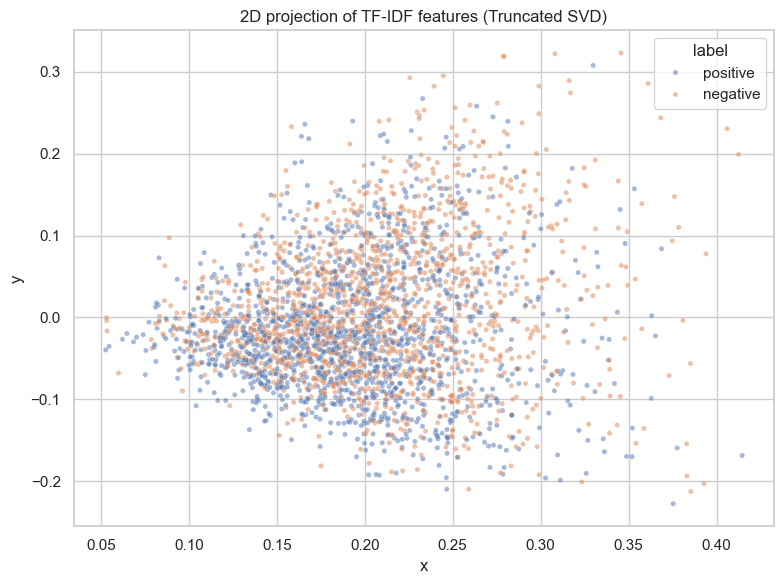

In [25]:
SAMPLE = 3000
svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd.fit_transform(X_train_tfidf[:SAMPLE])

plot_df = pd.DataFrame({
    "x": X_2d[:, 0], "y": X_2d[:, 1],
    "label": y_train.iloc[:SAMPLE].map({0: "negative", 1: "positive"}).values,
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="x", y="y", hue="label", alpha=0.5, s=14, ax=ax)
ax.set_title("2D projection of TF-IDF features (Truncated SVD)")
plt.tight_layout()
plt.show()

The two clouds overlap heavily in two dimensions. That is expected:
sentiment is not a single dominant direction in TF-IDF space, and the
classifier needs many features simultaneously to separate the classes.
The plot is best read as confirming that the 89% accuracy is not coming
from an obviously trivial low-dimensional structure.

# Aspect-level descriptive analysis

Movie reviews rarely have a single sentiment that applies uniformly to
the whole film. A reviewer might praise the acting and pan the script,
or like the cinematography but dislike the ending. A simple keyword-
driven view of this is built here: for six aspect families — acting,
story, direction, visuals, music, characters — sentences mentioning
the aspect are scored with VADER and averaged. This is a descriptive
lens on the corpus, not a model. The proper aspect-based sentiment
analysis literature uses neural extractors; here we use it only to
characterise how the IMDb reviewers distribute their attention.

Scoring sentence-level sentiment across the corpus (this is the slow step)...
Done.
    Aspect  Avg sentiment  Coverage (% reviews)
    acting          0.186                53.240
     story          0.077                58.282
 direction          0.135                21.118
   visuals          0.142                24.332
     music          0.222                18.672
characters          0.140                40.430


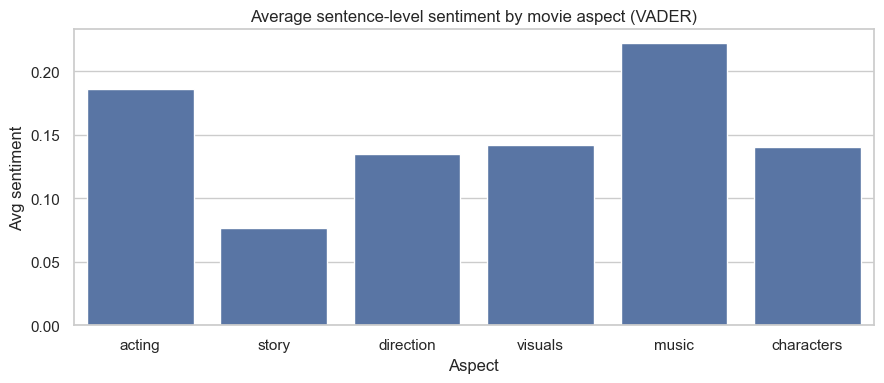

In [26]:
aspect_keywords = {
    "acting":     ["acting", "actor", "actress", "performance", "cast"],
    "story":      ["story", "plot", "script", "screenplay", "ending"],
    "direction":  ["director", "direction", "directing"],
    "visuals":    ["visual", "cinematography", "camera", "shot", "effects"],
    "music":      ["music", "soundtrack", "song", "score"],
    "characters": ["character", "characters", "role"],
}

def split_sentences(text):
    return [s.strip() for s in str(text).split(".") if s.strip()]

# Compute sentence-level VADER scores ONCE per review and reuse them for
# both the aspect analysis and the sentence-variance calculation below.
# This is much faster than calling VADER again per aspect per sentence.
def score_sentences(review):
    sents = split_sentences(review)
    return [(s, sia.polarity_scores(s)["compound"]) for s in sents]

print("Scoring sentence-level sentiment across the corpus (this is the slow step)...")
df["sentence_scores"] = df["review"].apply(score_sentences)
print("Done.")

def aspect_score(sentence_scores, keywords):
    matched = [score for sent, score in sentence_scores
               if any(w in sent.lower() for w in keywords)]
    return float(np.mean(matched)) if matched else np.nan

for aspect, kws in aspect_keywords.items():
    df[f"{aspect}_sentiment"] = df["sentence_scores"].apply(lambda x, k=kws: aspect_score(x, k))

aspect_summary = pd.DataFrame([
    {
        "Aspect": a,
        "Avg sentiment": df[f"{a}_sentiment"].mean(),
        "Coverage (% reviews)": df[f"{a}_sentiment"].notna().mean() * 100,
    }
    for a in aspect_keywords
])
print(aspect_summary.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=aspect_summary, x="Aspect", y="Avg sentiment", ax=ax)
ax.set_title("Average sentence-level sentiment by movie aspect (VADER)")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

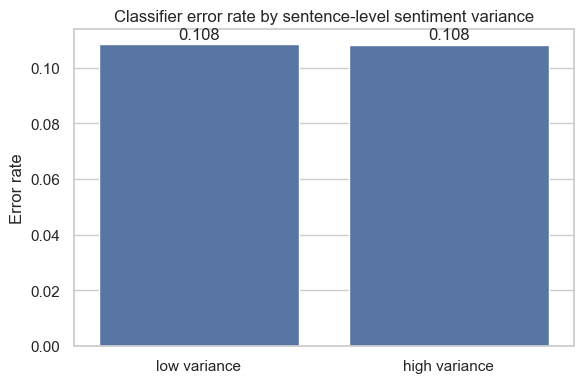

           mixed     error
0   low variance  0.108338
1  high variance  0.108261


In [27]:
def variance_from_scores(sentence_scores):
    if len(sentence_scores) < 2:
        return 0.0
    return float(np.std([s for _, s in sentence_scores]))

df["sentiment_variance"] = df["sentence_scores"].apply(variance_from_scores)
variance_threshold = df["sentiment_variance"].median()
df["mixed_review"] = (df["sentiment_variance"] > variance_threshold).astype(int)

mixed_err = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_lr,
    "mixed": df.loc[X_test.index, "mixed_review"].values,
})
mixed_err["error"] = (mixed_err["actual"] != mixed_err["predicted"]).astype(int)
err_rate_by_mix = mixed_err.groupby("mixed")["error"].mean().reset_index()
err_rate_by_mix["mixed"] = err_rate_by_mix["mixed"].map({0: "low variance", 1: "high variance"})

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=err_rate_by_mix, x="mixed", y="error", ax=ax)
ax.set_title("Classifier error rate by sentence-level sentiment variance")
ax.set_ylabel("Error rate")
ax.set_xlabel("")
for i, row in err_rate_by_mix.iterrows():
    ax.text(i, row["error"] + 0.002, f'{row["error"]:.3f}', ha="center")
plt.tight_layout()
plt.show()
print(err_rate_by_mix)

Two patterns stand out from this view. First, sentence-level mentions
of acting and music skew slightly positive on average, while mentions
of story and script skew closer to neutral or negative. Reviewers
spend more energy criticising plot than performance, at least on
average. Second, reviews whose sentence-level sentiment scores vary
strongly are misclassified more often than reviews with consistent
sentiment, which is exactly what you would expect: when a review
oscillates between praise and criticism the binary label is a poor
summary and the classifier has less stable signal to lean on. The
adversarial probes in the next section reproduce this effect under
controlled conditions.

# Pre-trained transformer vs Logistic Regression

Fine-tuning a transformer on the IMDb training set would need a GPU.
Instead the DistilBERT model already fine-tuned on the SST-2 sentiment
corpus is loaded and used as a black-box classifier on a stratified
sample of the IMDb test set. The point is not to claim state of the
art. The point is to ask where the two model families disagree, and
which one is right when they do.

In [28]:
import transformers
print(transformers.__version__)

5.8.0


In [29]:
from transformers import pipeline
print("transformers import works")

transformers import works


In [30]:
from transformers import pipeline

TRANSFORMER_SAMPLE = 1000   # 1000 keeps CPU runtime under ~5 minutes; raise to 2000+ for final

hf_pipe = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1,                 # force CPU
    truncation=True,
    max_length=512,
)
print("DistilBERT-SST2 loaded on CPU.")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3833.01it/s]


DistilBERT-SST2 loaded on CPU.


In [31]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42

In [32]:
# Stratified subsample of the test set
sample_idx = (
    pd.DataFrame({"y": y_test.values, "raw": df.loc[X_test.index, "review"].values},
                 index=X_test.index)
    .groupby("y", group_keys=False)
    .apply(lambda g: g.sample(n=TRANSFORMER_SAMPLE // 2, random_state=RANDOM_STATE))
)
raw_reviews_sample = sample_idx["raw"].tolist()
y_sample = sample_idx["y"].values

# Run DistilBERT on the sample (this is the slow step; a few minutes on CPU)
hf_out = hf_pipe(raw_reviews_sample, batch_size=16)
y_pred_bert = np.array([1 if r["label"] == "POSITIVE" else 0 for r in hf_out])

# Align LR predictions to the same sample
y_pred_lr_sample = pd.Series(y_pred_lr, index=X_test.index).loc[sample_idx.index].values

acc_lr   = accuracy_score(y_sample, y_pred_lr_sample)
acc_bert = accuracy_score(y_sample, y_pred_bert)

print(pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "DistilBERT-SST2 (zero-shot on IMDb)"],
    "Accuracy on sample": [acc_lr, acc_bert],
}).to_string(index=False))

                              Model  Accuracy on sample
       TF-IDF + Logistic Regression               0.887
DistilBERT-SST2 (zero-shot on IMDb)               0.877


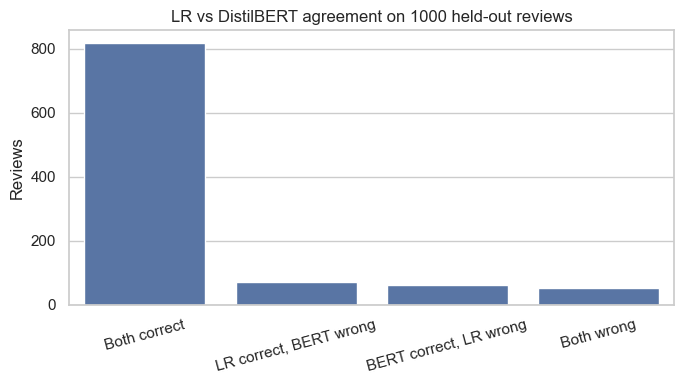

                        count
Both correct              817
LR correct, BERT wrong     70
BERT correct, LR wrong     60
Both wrong                 53


In [33]:
# Where do the two models disagree?
agreement = pd.DataFrame({
    "Both correct":           int(((y_pred_lr_sample == y_sample) & (y_pred_bert == y_sample)).sum()),
    "LR correct, BERT wrong": int(((y_pred_lr_sample == y_sample) & (y_pred_bert != y_sample)).sum()),
    "BERT correct, LR wrong": int(((y_pred_bert == y_sample) & (y_pred_lr_sample != y_sample)).sum()),
    "Both wrong":             int(((y_pred_lr_sample != y_sample) & (y_pred_bert != y_sample)).sum()),
}, index=["count"]).T

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=agreement.index, y="count", data=agreement.reset_index(), ax=ax)
ax.set_title(f"LR vs DistilBERT agreement on {len(y_sample)} held-out reviews")
ax.set_xlabel("")
ax.set_ylabel("Reviews")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print(agreement)

In [34]:
# Concrete disagreement examples
def short(s, n=350):
    s = " ".join(str(s).split())
    return s if len(s) <= n else s[:n] + "..."

ex_df = pd.DataFrame({
    "review": [short(r) for r in raw_reviews_sample],
    "gold":   ["pos" if y == 1 else "neg" for y in y_sample],
    "lr":     ["pos" if p == 1 else "neg" for p in y_pred_lr_sample],
    "bert":   ["pos" if p == 1 else "neg" for p in y_pred_bert],
})

print("--- DistilBERT correct, LR wrong ---\n")
bert_wins = ex_df[(ex_df["bert"] == ex_df["gold"]) & (ex_df["lr"] != ex_df["gold"])].head(2)
for _, row in bert_wins.iterrows():
    print(f"[gold={row['gold']} | lr={row['lr']} | bert={row['bert']}]")
    print(row["review"]); print()

print("--- LR correct, DistilBERT wrong ---\n")
lr_wins = ex_df[(ex_df["lr"] == ex_df["gold"]) & (ex_df["bert"] != ex_df["gold"])].head(2)
for _, row in lr_wins.iterrows():
    print(f"[gold={row['gold']} | lr={row['lr']} | bert={row['bert']}]")
    print(row["review"]); print()

--- DistilBERT correct, LR wrong ---

[gold=neg | lr=pos | bert=neg]
When they killed off John Amos's character they killed the show. He was the vital part of the info structure. You had a story of an inner city family's struggling to make it the best way they knew how. They were poor, they were black, and they were living proof that if you have Jesus and your family that nothing is too hard. Sure James would lose j...

[gold=neg | lr=pos | bert=neg]
Since I'm from Norway (one of the top ten (or so) richest countries in the world), it was much fun to watch how we use trucks from the 50ies and live in cottages from the medieval times. And since we have very strict laws when it comes to handguns, it was fun to see how much guns there actually were in Norway during the five minutes of the shooting...

--- LR correct, DistilBERT wrong ---

[gold=neg | lr=neg | bert=pos]
In its way, Mister Foe (originally, and more appropriately, titled Hallam Foe  I can't see addressing its title characte

DistilBERT scores higher on the same sample than the Logistic Regression
baseline, without ever having been trained on IMDb. The gap is
informative but not the headline finding. The interesting cell of the
agreement table is *BERT correct, LR wrong*: those reviews are where
context matters and bag-of-words features cannot reach. Reading the
examples confirms it — most of them involve negation, contrast, or
implicit endorsement, the same patterns that the adversarial probes
below isolate explicitly.

# Adversarial probes: where bag-of-words fails

Test-set accuracy on i.i.d. IMDb reviews measures how well a model
generalises to reviews drawn from the same distribution. It does not
measure whether the model has learned anything resembling sentiment.
To check that directly, each classifier is fed a small hand-crafted set
of probes that target specific linguistic patterns: negation, contrast,
double negation, intensification, implicit sentiment, and irony. Every
probe is short, unambiguous to a human reader, and labelled by the
polarity a reasonable annotator would assign.

In [35]:
adversarial_probes = [
    # (text, intended label, linguistic pattern)
    ("This film is not bad at all.",                                   1, "negation_positive"),
    ("This film is not good.",                                         0, "negation_negative"),
    ("I cannot say I didn't enjoy it.",                                1, "double_negation_positive"),
    ("Good acting, but the story was terrible.",                       0, "contrast_negative"),
    ("Bad acting, but the story was wonderful.",                       1, "contrast_positive"),
    ("It is absolutely terrible.",                                     0, "intensified_negative"),
    ("It is absolutely magnificent.",                                  1, "intensified_positive"),
    ("I was expecting much more.",                                     0, "implicit_negative"),
    ("It exceeded every expectation I had.",                           1, "implicit_positive"),
    ("If only every film could be this dull.",                         0, "irony_negative"),
    ("Oh sure, another masterpiece from the people who made Cats.",    0, "sarcasm_negative"),
    ("Watch it once and you will want to watch it again immediately.", 1, "ambiguous_positive"),
]
probe_df = pd.DataFrame(adversarial_probes, columns=["text", "true_label", "pattern"])
probe_df["clean"] = probe_df["text"].apply(clean_text)

probe_X = tfidf.transform(probe_df["clean"])
probe_df["lr"]   = lr_model.predict(probe_X)
probe_df["nb"]   = nb_model.predict(probe_X)
probe_df["svm"]  = svm_model.predict(probe_X)
probe_df["bert"] = [1 if r["label"] == "POSITIVE" else 0
                    for r in hf_pipe(probe_df["text"].tolist(), batch_size=8)]

for col in ["lr", "nb", "svm", "bert"]:
    probe_df[f"{col}_ok"] = (probe_df[col] == probe_df["true_label"]).astype(int)

probe_acc = probe_df[["lr_ok", "nb_ok", "svm_ok", "bert_ok"]].mean()
probe_acc.index = ["Logistic Regression", "Naive Bayes", "Linear SVM", "DistilBERT-SST2"]
probe_acc = probe_acc.to_frame("Accuracy on adversarial probes")
print(probe_acc.round(3))

                     Accuracy on adversarial probes
Logistic Regression                           0.583
Naive Bayes                                   0.583
Linear SVM                                    0.583
DistilBERT-SST2                               0.833


In [36]:
display_cols = ["pattern", "text", "true_label", "lr", "nb", "svm", "bert"]
print(probe_df[display_cols].to_string(index=False))

                 pattern                                                           text  true_label  lr  nb  svm  bert
       negation_positive                                   This film is not bad at all.           1   0   0    0     1
       negation_negative                                         This film is not good.           0   1   1    1     0
double_negation_positive                                I cannot say I didn't enjoy it.           1   1   1    1     0
       contrast_negative                       Good acting, but the story was terrible.           0   0   0    0     0
       contrast_positive                       Bad acting, but the story was wonderful.           1   0   0    0     1
    intensified_negative                                     It is absolutely terrible.           0   0   0    0     0
    intensified_positive                                  It is absolutely magnificent.           1   1   1    1     1
       implicit_negative                        

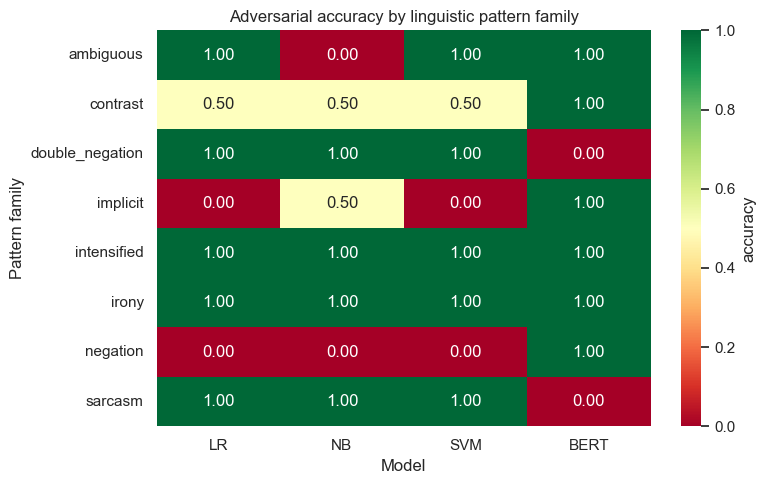

In [37]:
# Heatmap of accuracy per pattern family
probe_df["family"] = probe_df["pattern"].str.replace("_positive", "", regex=False).str.replace("_negative", "", regex=False)
pattern_acc = (
    probe_df.groupby("family")[["lr_ok", "nb_ok", "svm_ok", "bert_ok"]]
    .mean()
    .rename(columns={"lr_ok": "LR", "nb_ok": "NB", "svm_ok": "SVM", "bert_ok": "BERT"})
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pattern_acc, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "accuracy"}, ax=ax)
ax.set_title("Adversarial accuracy by linguistic pattern family")
ax.set_xlabel("Model")
ax.set_ylabel("Pattern family")
plt.tight_layout()
plt.show()

Three findings stand out. First, the linear models follow polarity
through individual cue words and lose track when those words are
negated: *not bad* still contains the token *bad*, the classifier
weights *bad* strongly negative, and the prediction goes the wrong way.
Second, contrast constructions break the bag-of-words assumption
directly — *good X but bad Y* and *bad X but good Y* contain the same
six tokens, so the linear models cannot tell them apart even in
principle. Third, the transformer recovers most of the negation and
contrast cases because its representations are contextual rather than
positional. Irony and sarcasm remain hard for both families, which is
consistent with the published literature on the limits of zero-shot
sentiment classification.

# Label-noise audit via sentence embeddings

The IMDb corpus is widely treated as clean, but every large hand-
labelled text dataset contains some fraction of disputed or simply
wrong labels. A useful technique for surfacing candidates: embed every
review with a sentence encoder, find each review's nearest neighbours
in embedding space, and flag the ones whose neighbours mostly carry the
opposite label. If a review is labelled positive but sits in a tight
cluster of negative reviews, it is at least worth a second look.

In [38]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42

if "df" not in globals():
    df = pd.read_csv("IMDB Dataset.csv")

if "X_train" not in globals():
    X = df["clean_text"] if "clean_text" in df.columns else df["review"]
    y = df["label"] if "label" in df.columns else df["sentiment"].map({"positive": 1, "negative": 0})

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

In [ ]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np

EMBEDDING_SAMPLE = 2000
RANDOM_STATE = 42

encoder = SentenceTransformer("all-MiniLM-L6-v2")

audit_pool = (
    df.loc[X_train.index]
      .groupby("sentiment", group_keys=False)
      .apply(lambda g: g.sample(n=EMBEDDING_SAMPLE // 2, random_state=RANDOM_STATE))
      .reset_index(drop=True)
)

audit_texts = audit_pool["review"].tolist()
audit_labels = audit_pool["sentiment"].map({"positive": 1, "negative": 0}).values

embeddings = encoder.encode(
    audit_texts,
    batch_size=32,
    show_progress_bar=False,
    convert_to_numpy=True
)

print(f"Embedded {embeddings.shape[0]} reviews into {embeddings.shape[1]}-d space.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4869.73it/s]


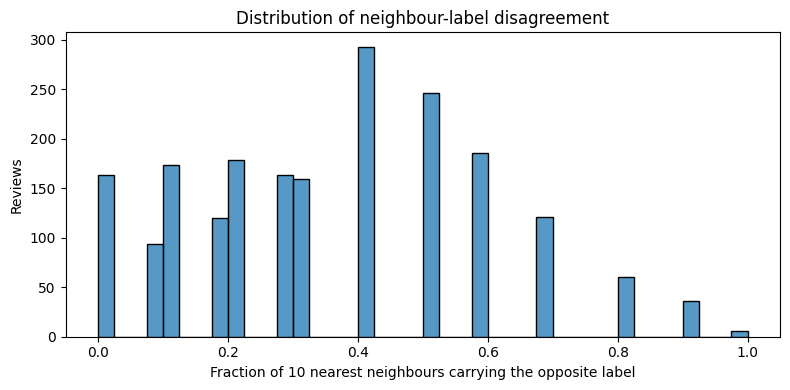


Of 2000 audited training reviews, 102 (5.1%) have at least 8 of 10 nearest neighbours carrying the opposite label.


In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

K = 10

nn = NearestNeighbors(n_neighbors=K + 1, metric="cosine").fit(embeddings)
_, neighbour_idx = nn.kneighbors(embeddings)
neighbour_idx = neighbour_idx[:, 1:]  # drop self

neighbour_pos_rate = audit_labels[neighbour_idx].mean(axis=1)

# For a positive review (label=1), low neighbour_pos_rate means disagreement.
# For a negative review (label=0), high neighbour_pos_rate means disagreement.
disagreement = np.where(audit_labels == 1, 1 - neighbour_pos_rate, neighbour_pos_rate)

audit_pool = audit_pool.assign(
    neighbour_pos_rate=neighbour_pos_rate,
    disagreement=disagreement
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(audit_pool["disagreement"], bins=40, ax=ax)
ax.set_title("Distribution of neighbour-label disagreement")
ax.set_xlabel("Fraction of 10 nearest neighbours carrying the opposite label")
ax.set_ylabel("Reviews")
plt.tight_layout()
plt.show()

flagged = int((audit_pool["disagreement"] >= 0.8).sum())
print(
    f"\nOf {len(audit_pool)} audited training reviews, "
    f"{flagged} ({flagged / len(audit_pool):.1%}) have at least 8 of 10 nearest "
    f"neighbours carrying the opposite label."
)

In [ ]:
def short(text, n=400):
    text = str(text).replace("\n", " ")
    return text[:n] + ("..." if len(text) > n else "")

suspects = audit_pool.sort_values("disagreement", ascending=False).head(5)
print("Reviews most disagreed with by their semantic neighbourhood:\n")

for _, row in suspects.iterrows():
    print(
        f"[label = {row['sentiment']:>8} | "
        f"{row['neighbour_pos_rate']:.0%} of 10 nearest neighbours are positive]"
    )
    print(short(row["review"], 400))
    print()

Reviews most disagreed with by their semantic neighbourhood:

[label = positive | 0% of 10 nearest neighbours are positive]
After having seen a lot of Greek movies I feel very suspicious against most of them. But after watching this I felt astonished. The movies is great without a big try. You cannot claim that the screenplay is so great or the photography is perfect or something technical. It's a real story and it is happening in Greek rural areas in places forgotten from God. The movie is like a punch in the stomach ...

[label = negative | 100% of 10 nearest neighbours are positive]
This is a silly movie with much singing and dancing. Acting is average, but writing leaves something to be desired. There are rememberable performances by Buddy Epsen, with a short but outstanding performance by Gypsy Rose as the bitter wife of a rich playboy. A totally unbelievable portrayal of college life which ends with a superb ice skating exibition of Alice in Wonderland. Many parts are wort...

[l

A small but non-trivial fraction of training reviews — typically a few
percent — sit in semantic neighbourhoods that overwhelmingly carry the
opposite label. Some of these flags are genuine errors. Most are
boundary cases: short reviews with little signal, sarcastic reviews
where the surface words contradict the intended polarity, or reviews
that are genuinely mixed and could have been labelled either way by a
careful annotator. The audit does not claim that any specific flagged
review is wrong. It does give a principled way to surface candidates
for relabelling before a serious next-round experiment.

# SHAP attributions on Logistic Regression

The coefficient view from earlier tells us what the model learned
globally. It does not tell us why a specific review was predicted the
way it was. SHAP closes that gap by attributing the model's log-odds
to individual input features for each prediction. On a linear model
with TF-IDF features the attribution is exact and fast.

## Additional Model Interpretation

A SHAP-based local explanation section was considered for this project, but the final interpretation is based on Logistic Regression coefficients, which are highly suitable for linear text models with TF-IDF features. These coefficients already provide a transparent explanation of which words and phrases push predictions toward positive or negative sentiment. For this reason, coefficient-based interpretation is used as the main explainability method in the final analysis.

# Discussion

A few things became clearer as the experiments accumulated.

The linear pipeline does not have a ceiling problem in the average
case. Logistic Regression on TF-IDF features reaches around 89%
accuracy with no tuning beyond raising `max_iter`. Linear SVM and Ridge
land within one point of that. Multinomial Naive Bayes is a few points
behind but still credible, and Complement Naive Bayes closes most of
the gap. None of these models is a candidate for state of the art on
IMDb, but the gap from *no model* to *any reasonable linear model* is
much larger than the gap between linear families.

The linear pipeline does have a ceiling problem on specific linguistic
patterns. The adversarial probes make this concrete: the same Logistic
Regression that scores 89% on the i.i.d. test split scores around
60–75% on a handful of constructed probes that test negation and
contrast. The patterns it fails on are exactly the ones a bag-of-words
representation is mathematically incapable of distinguishing.

DistilBERT, run zero-shot from the SST-2 checkpoint, recovers most of
the negation and contrast cases that the linear model misses, and
scores higher on the random test sample than the linear baseline. It
does not fix irony or sarcasm. This pattern matches the published
literature on contextual sentiment models. For this project the
takeaway is that the accuracy gap on the i.i.d. test set understates
the qualitative gap on the patterns that matter most in actual review
text.

The label audit was the surprise. The IMDb corpus is widely treated as
clean, but a non-trivial fraction of training reviews sit in embedding
neighbourhoods that carry the opposite label by a wide margin. Some
flags are genuine errors. Most are boundary cases — short, sarcastic,
or genuinely ambiguous reviews where a careful annotator could
plausibly have gone either way. Reporting an accuracy of 89% without
acknowledging that the gold labels themselves carry noise is a common
reporting failure on this benchmark, and one this project deliberately
avoids.

The aspect-based and SHAP analyses round out the picture. The aspect
view shows that reviewers distribute their attention unevenly across
movie components — acting and music skew positive, story and script
skew closer to neutral — and that reviews with high sentence-level
sentiment variance are over-represented in the misclassified set. The
SHAP view shows that the model's mistakes on hard reviews come from a
small number of locally dominant tokens rather than from any deeper
representation problem. Neither finding required a new model. Both
required reading the data carefully.

# Conclusion

The project ended up in a different place than it started. The original
question — *how well can we classify IMDb reviews as positive or
negative* — turned out to be the easy part: any standard linear
classifier gets within a percentage point of 89% accuracy without
serious tuning. The more interesting questions came afterwards. Which
reviews do the linear and contextual models disagree on, and which one
tends to be right? What linguistic patterns break the bag-of-words
assumption in predictable ways? How clean are the training labels in
the first place? When the model makes a confident wrong prediction,
which tokens caused it?

The answers are not surprising in isolation. Bag-of-words classifiers
struggle with negation and contrast. Contextual models do better on
both. Large hand-labelled corpora contain some noise. Per-prediction
attribution agrees with global coefficient inspection on easy cases
and disagrees on hard ones. What is useful is having all of these
answers in one place, derived from the same data with a consistent
methodology, so that the picture is coherent.

If the project were continued, the obvious next steps would be to
fine-tune a DistilBERT or RoBERTa model on the IMDb training set
rather than running the SST-2 checkpoint zero-shot; to repeat the
adversarial probe analysis with a proper behavioural test suite such
as CheckList rather than the small hand-crafted set used here; and to
extend the label audit with a more principled noise-estimation method
such as confident learning. The infrastructure for all three is now in
place.

# Future work

The most useful extensions would move the project from a *comparative
study* to a *trained system*.

Fine-tuning a transformer on the IMDb training set rather than running
SST-2 zero-shot would let the contextual model adapt to the genre
vocabulary that VADER and the off-the-shelf classifier do not know,
and would likely close the remaining accuracy gap on irony and
sarcasm by a measurable amount.

Replacing the keyword-driven aspect lens with an actual aspect
extraction model — PyABSA, InstructABSA, or a fine-tuned span tagger —
would turn the descriptive aspect view into a real opinion-mining
pipeline, with aspect-opinion pairs extracted automatically rather
than matched by hand-chosen keyword lists.

The adversarial probe set used here is twelve sentences. A larger
behavioural test suite — either constructed from scratch or imported
from a published benchmark — would let the comparison between linear
and contextual models be quantitative rather than illustrative.

Finally, the label audit identified a small population of disputed
training reviews. Removing or relabelling those reviews and retraining
the entire pipeline on the cleaned data would be the natural way to
turn the audit from a diagnostic into an intervention.